# Importing the requirements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

Load the csv data as DataFrame

In [2]:
df = pd.read_csv("Visadata.csv")


Top 5 Records

In [3]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


Shape of the dataset

In [4]:
df.shape

(25480, 12)

Summary of the dataset

In [5]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


Check Datatypes in the dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


# Exploring Data

In [7]:
# define numerical & categorical column
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype =='O']

# Print columns
print('we have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('we have {} categorical features : {}'.format(len(categorical_features), categorical_features))

we have 3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
we have 9 categorical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [8]:
# Proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)
    print('-------------------------')

case_id
EZYV01       0.003925
EZYV16995    0.003925
EZYV16993    0.003925
EZYV16992    0.003925
EZYV16991    0.003925
               ...   
EZYV8492     0.003925
EZYV8491     0.003925
EZYV8490     0.003925
EZYV8489     0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
-------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
-------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
-------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
-------------------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
-------------------------
region_of_employment
Northeast    28.237834
S

# Univariate Analysis

- The term univariate analysis refers to the analysis of one variable prefix "uni" means "one". The purpose     of univariate analysis is to understand the distribution of values for a single variable.

Other Type of analysis:-

- Bivariate Analysis:- The analysis of two variables.

- Multivariate Analysis: The analysis of two or more variables.

Numerical Features

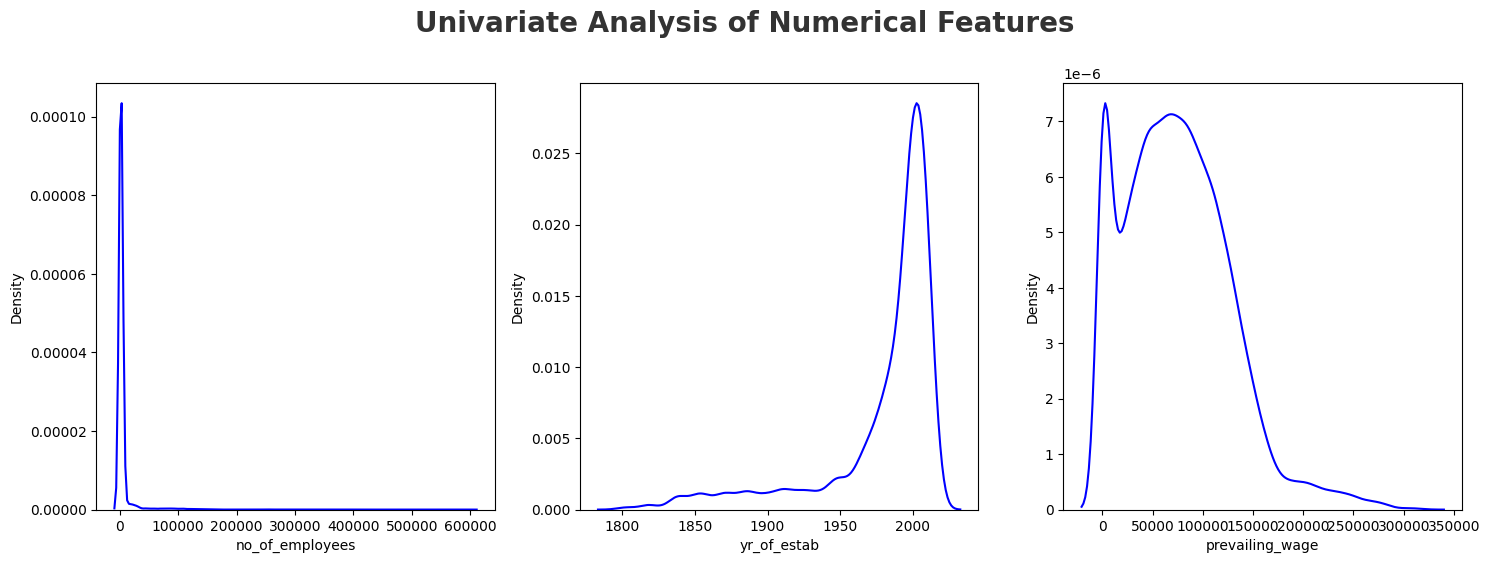

In [9]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1)

for i in range(0, len(numeric_features)):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

Insights

- no_of_employees columns looks more skewed but it may be because of outliers.
- yr_of_estab is a discrete feature.
- privailing-wage is a right skewed distribution.

# Categorical Features

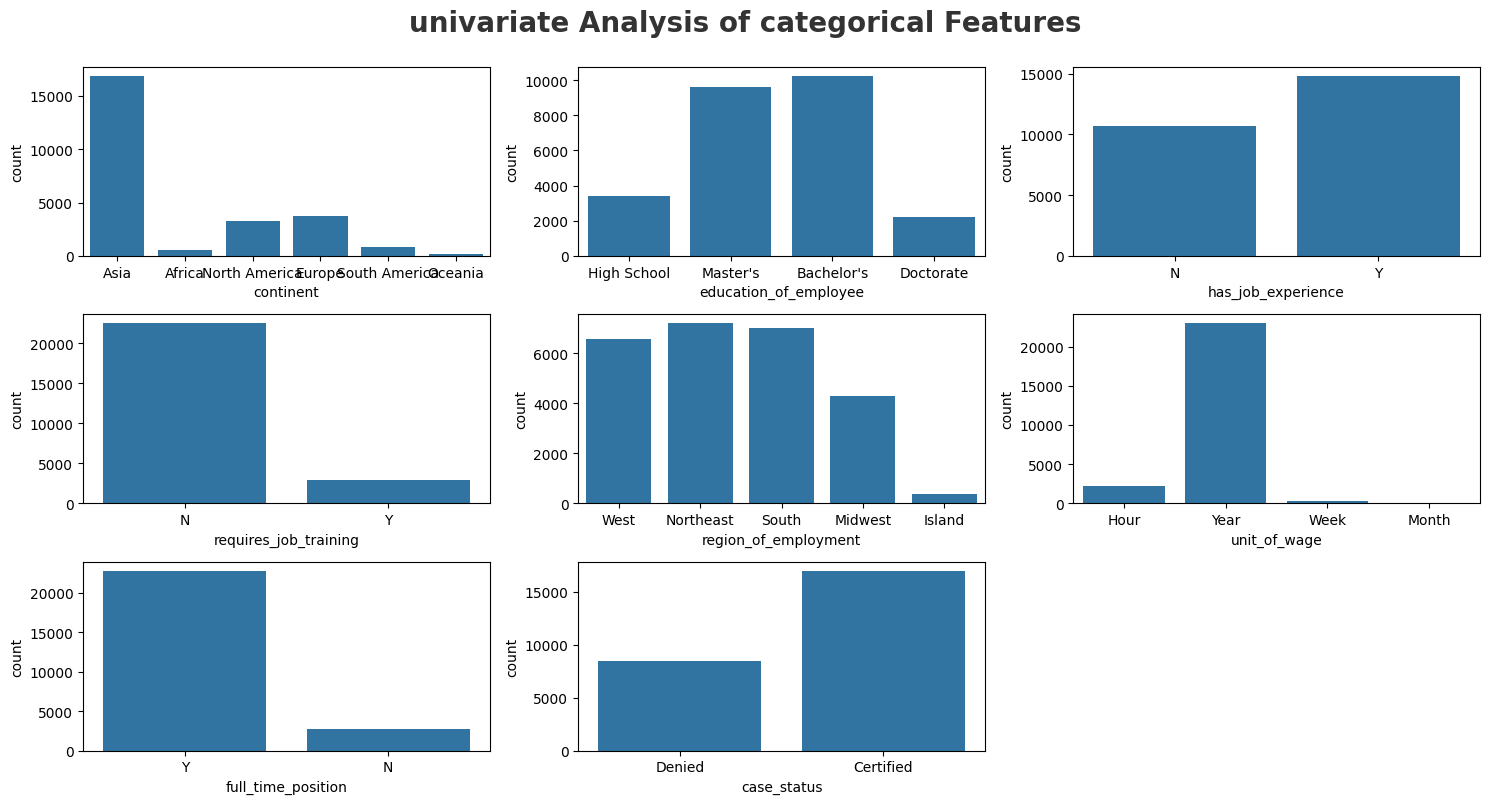

In [10]:
# Categorical Features
categorical_features.remove('case_id')
plt.figure(figsize=(15,8))
plt.suptitle('univariate Analysis of categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1)

for i in range(0, len(categorical_features)):
    plt.subplot(3,3,i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

Insights

- requires_job_training, unit_of_wage, full_time_possition and continents columns have single category          dominating.

- In rest of the columns are balanced.

# Multivariate Analysis

- Multivariate analysis is the analysis of more than one variable.

In [11]:
discrete_features = [feature for feature in numeric_features if len(df[feature].unique()) <= 25]

continuous_features = [feature for feature in numeric_features if len(df[feature].unique()) > 25]

print('We have {} discrete features : {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous_features : {}'.format(len(continuous_features), continuous_features))

We have 0 discrete features : []

We have 3 continuous_features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


# Check Multicolinearity in Numerical features

In [12]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


Insights

- There is no multicolinearity between any variables

# Check multicolinearity for Categorical Features

- A chi-squared test (also chi-square or X^2 test) is  statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test.

- A chi-squared statistic is one way to show a relationship between two categorical variables.

- Here we test correlation of categorical columns with target column i.e case_status

Null hypothesis(H0): The Feature is independent of target column (No-correlation)

Alternate Hypothesis(H1): The Feature and target Column are not independent(Correlated)

In [13]:
'''
from scipy.stats import chi2_contingency
chi2_test = []
for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[categorical_features, chi2_test])
result.columns = ['Column', 'Hypothesis Result']
result 

'''

"\nfrom scipy.stats import chi2_contingency\nchi2_test = []\nfor feature in categorical_features:\n    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:\n        chi2_test.append('Reject Null Hypothesis')\n    else:\n        chi2_test.append('Fail to Reject Null Hypothesis')\nresult = pd.DataFrame(data=[categorical_features, chi2_test])\nresult.columns = ['Column', 'Hypothesis Result']\nresult \n\n"

# Checking Null values

In [14]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [15]:
continuous_features = [feature for feature in numeric_features if len(df[feature].unique())>=10]
print('Num of continues features :', continuous_features)

Num of continues features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


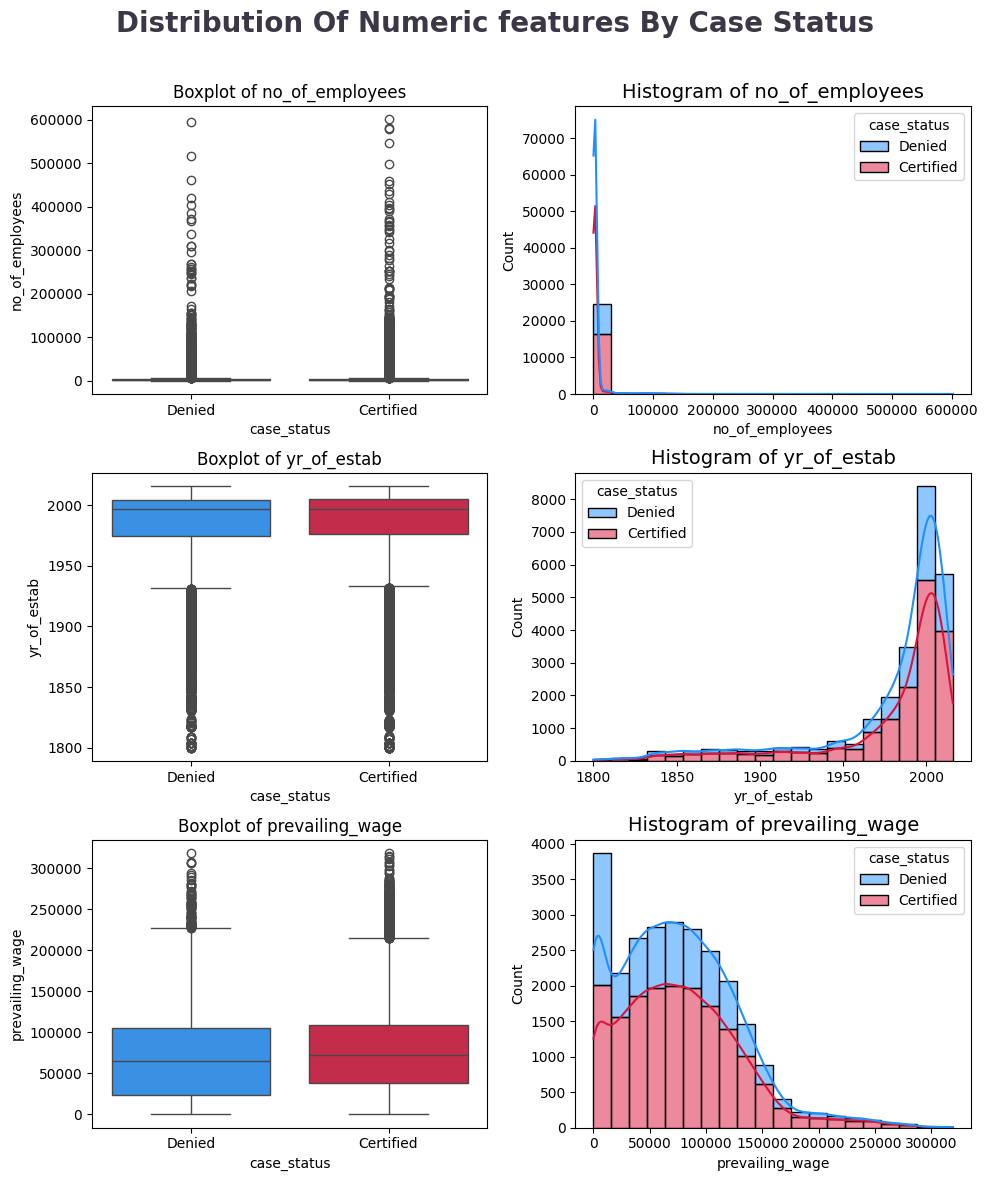

In [16]:
clr1 = ['#1E90FF', '#DC143C']
fig, ax = plt.subplots(3, 2, figsize=(10,12))
fig.suptitle('Distribution Of Numeric features By Case Status', color = '#3c3744', fontsize=20,             fontweight='bold', ha='center')
for i, col in enumerate(continuous_features):
    sns.boxplot(data=df, x='case_status', y=col, palette=clr1, ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col}', fontsize=12)
    sns.histplot(data=df, x=col,hue='case_status', bins=20, kde=True, 
                 multiple='stack', palette=clr1, ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.90)


# Initial Analysis Report

- No of Empolyees has many outliers which can be handled in Feature Engineering and no_of_employees is right Skewed.
- yr_of_estab is left skewed and some outlires belows the lower bound of Box Plot.
- previling_wage is right skewed with Outlires above upper bound of Box Plot.
- There are No missing Values in the dataset.
- The case_id column can be deleted because each row has unique values.
- The case_status column is the target to predict.
- In The Categorical column, features can be made Binary numerical in feature Encoding.


# Visualization

Visualize The Target Feature

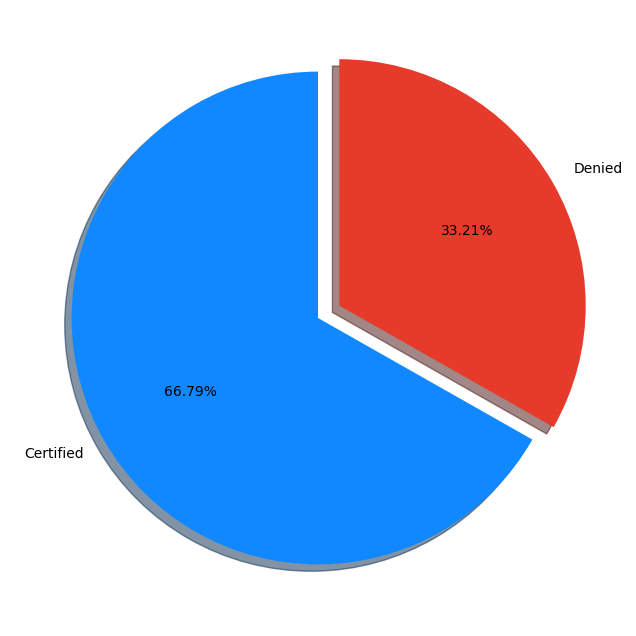

In [17]:
percentage = df.case_status.value_counts(normalize = True)*100
labels = ["Certified", "Denied"]

# Plot PieChart with Plotly Library

fig, ax = plt.subplots(figsize=(15, 8))
explode = (0,0.1)
colors = ['#1188ff', '#e63a2a']
ax.pie(
       percentage, 
       labels=labels,
       startangle=90, 
       autopct='%1.2f%%', 
       explode=explode, 
       shadow = True, 
       colors = colors
)
plt.show() 

- From the chart it is seen that the Target Variable is Imbalanced **What is Imbalanced Data**?

Imbalanced data are types of data where target class has an uneven distribution of Onservations, i.e Here Denied value has count than the certified value of the dataset.

# Does applicant continent has any impact on visa status?

In [18]:
# Group data by continent and their count of case_status
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100 

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

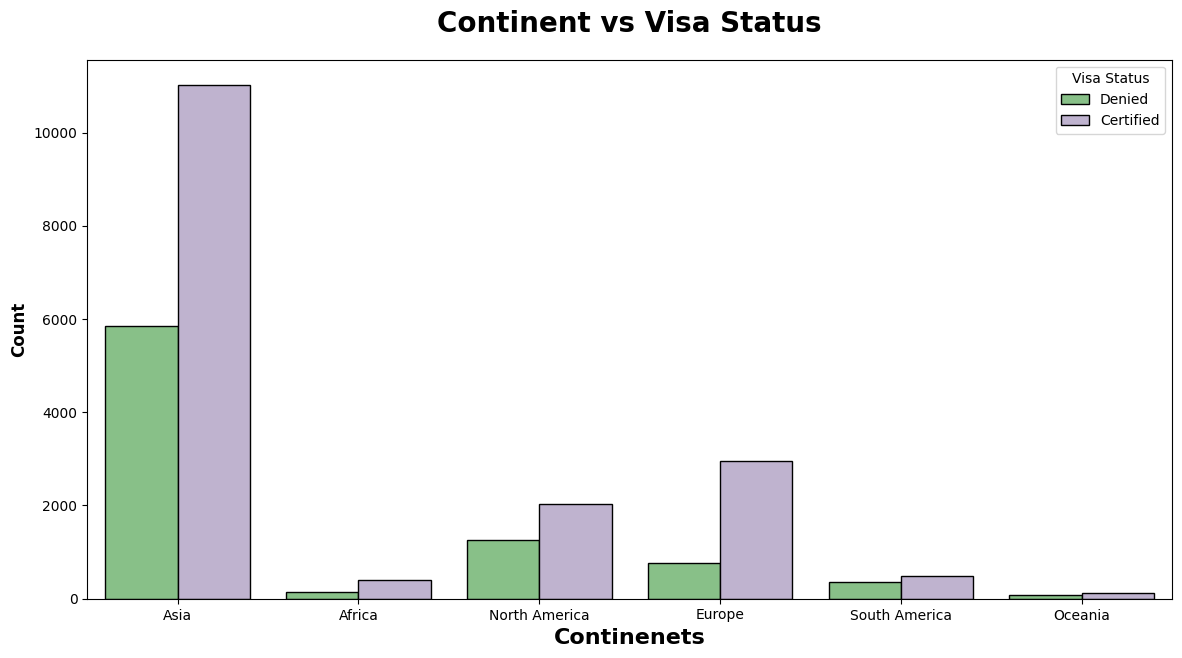

In [19]:
plt.subplots(figsize=(14,7))
sns.countplot(x="continent", hue="case_status", data=df, ec="black", palette="Accent")
plt.title("Continent vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Continenets", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

- As per the Chart Asia applicants applied more than other continents.
- 43% of certified applications are from Asia.
- This is followed by Europe with 11% of certified application.
- Highest Chance of getting certified if you are from Europe and Followed By Africa.

# Does applicant education has any impact on Visa Status ?

In [20]:
# group data by Education and their count of case_status
df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame()*100


proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

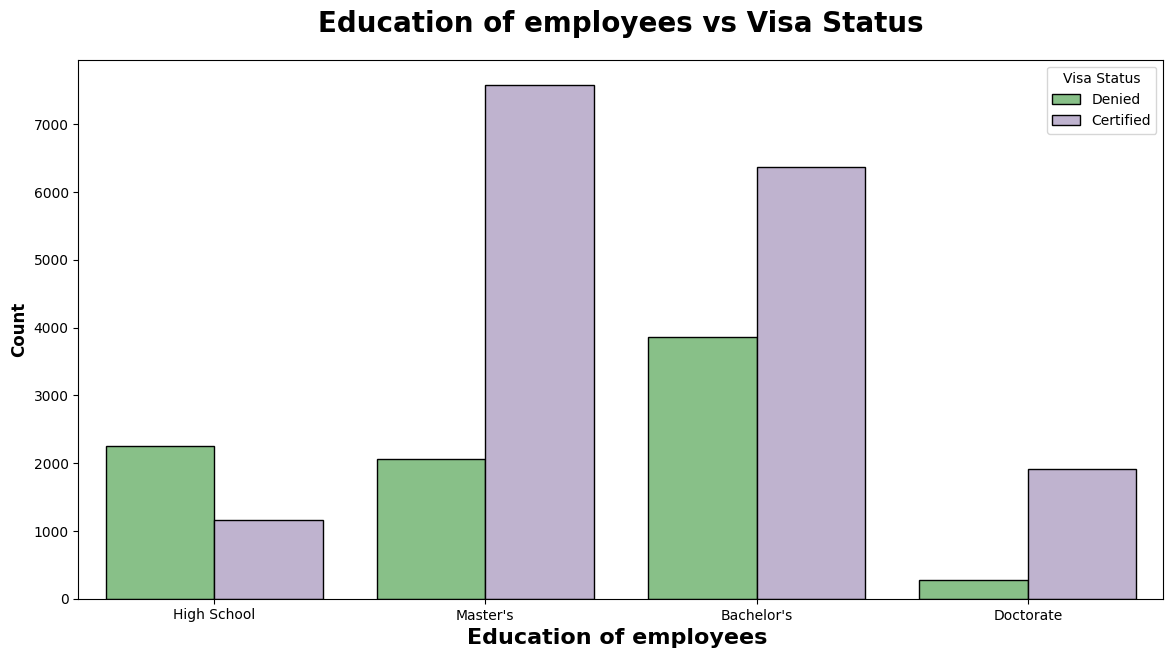

In [21]:
plt.subplots(figsize=(14,7))
sns.countplot(x="education_of_employee", hue="case_status", data=df, ec="black", palette="Accent")
plt.title("Education of employees vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Education of employees ", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

**Insight**
- Education status has high impact.
- **Doctorate** and **Master's** graduates have higher cange of being accepted then the others.

# Does applicant's previous work experience has any impact on visa status?

In [22]:
# group data by Experience and their count of case_status
df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).to_frame()*100


proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

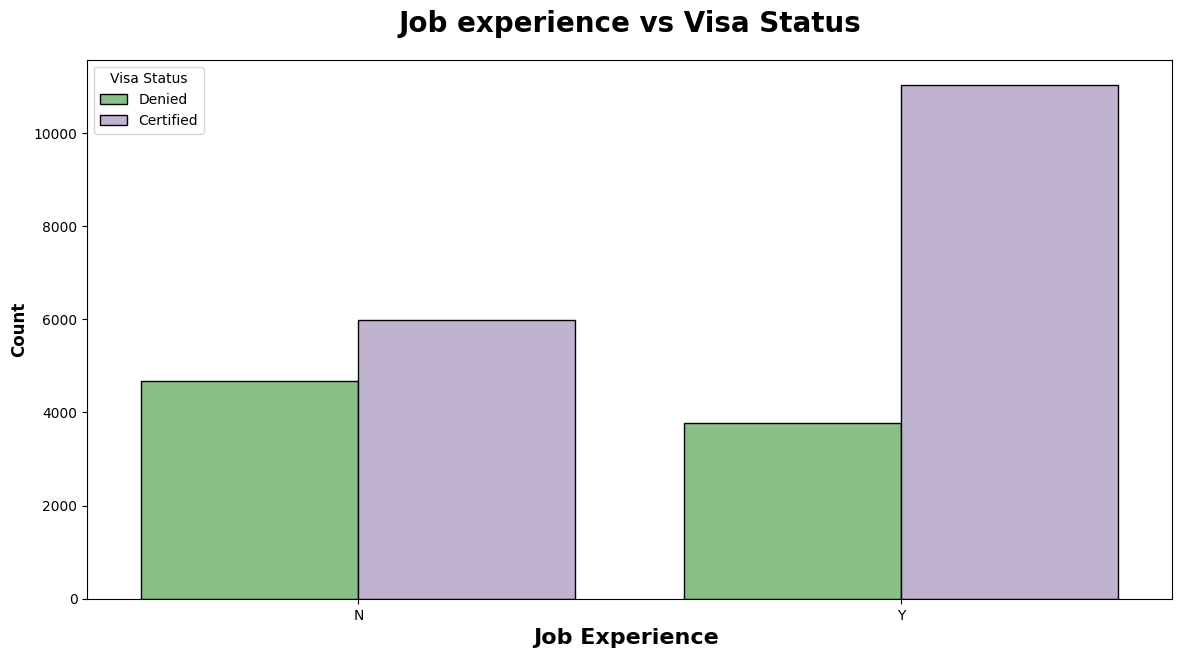

In [23]:
plt.subplots(figsize=(14,7))
sns.countplot(x="has_job_experience", hue="case_status", data=df, ec="black", palette="Accent")
plt.title("Job experience vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Job Experience ", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

**Report**
- People with previous work experience has been certified 74.5% and only 25.5% applicant has been denied.
- People With No previous work expetrience has been certified 56% and denied 43%.
- this Means work experience has effect on Visa Status.
- There is a slight edge for the people with work experience then the fresheres as expected. But the difference is not huge.

# If the Employee requires job training, does it make any impact on visa status?

In [24]:
# group data by Experience and their count of case_status
df.groupby('requires_job_training')['case_status'].value_counts(normalize=True).to_frame()*100 

proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

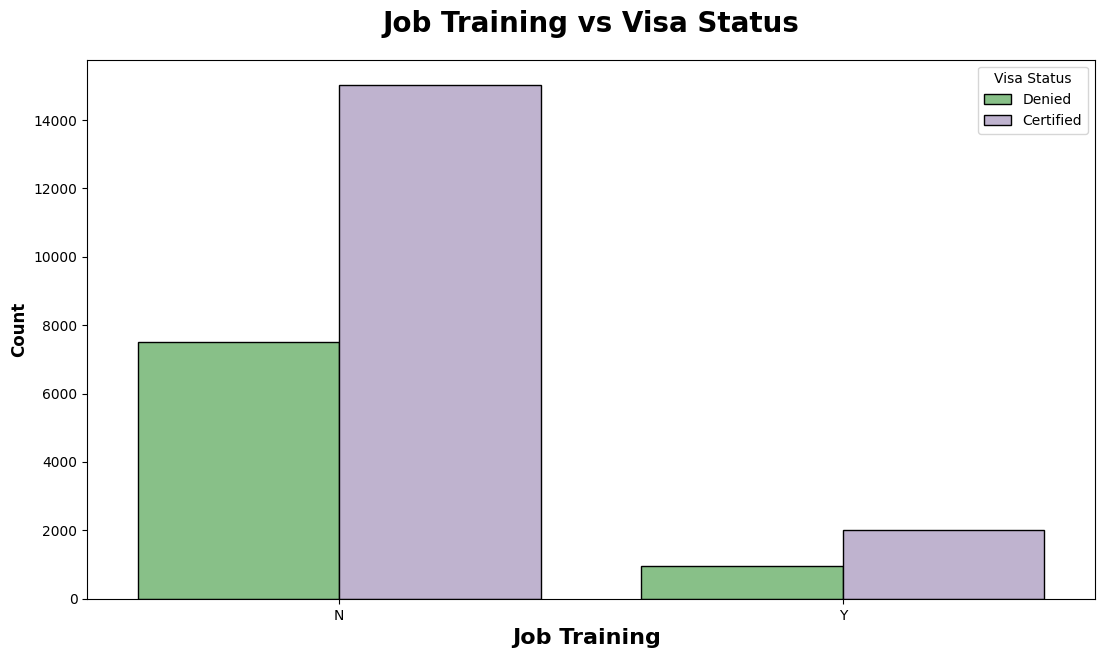

In [25]:
plt.subplots(figsize=(13,7))
sns.countplot(x="requires_job_training", hue="case_status", data=df, ec="black", palette="Accent")
plt.title("Job Training vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Job Training ", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

**Report**
- If employee require job training and it doesn't have any effect on Visa status.
- 88% of applicant don't require job training.
- 63% of people who doesn't want job training got certified.
- For employees who require job training 67% of people got certified.
- As we checked in Chi-Squared test this feature doesn't have much impact on target variable, which is confirmed by above plot.

# Does Number of employees of employer has any impact on Visa status?

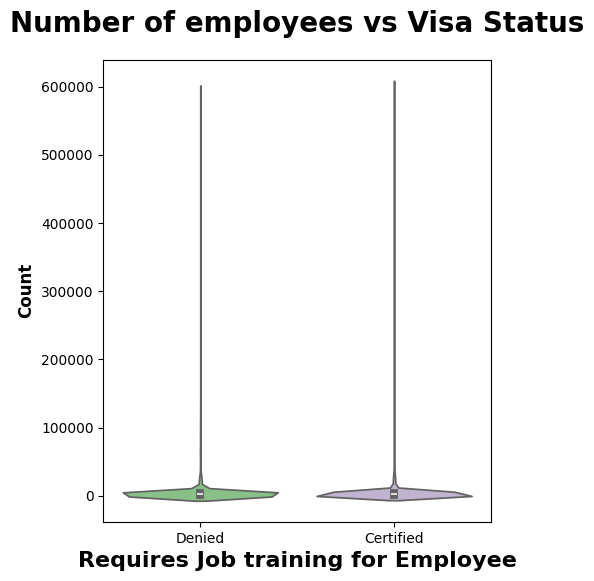

In [26]:
plt.subplots(figsize=(5,6))
sns.violinplot(x="case_status", y="no_of_employees", data=df, palette="Accent")
plt.title("Number of employees vs Visa Status", weight="bold",fontsize = 20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job training for Employee", weight="bold", fontsize=16)
plt.ylim()
plt.show()

**Insight**
- The distribution of both is similar. But there are outliers in both the classes which need to be handeled.

# Wages and its impact on visa status?

In [27]:
# group data by unit_of_wages and count the case_status
df.groupby('unit_of_wage')['case_status'].value_counts(normalize=True)

unit_of_wage  case_status
Hour          Denied         0.653686
              Certified      0.346314
Month         Certified      0.617978
              Denied         0.382022
Week          Certified      0.621324
              Denied         0.378676
Year          Certified      0.698850
              Denied         0.301150
Name: proportion, dtype: float64

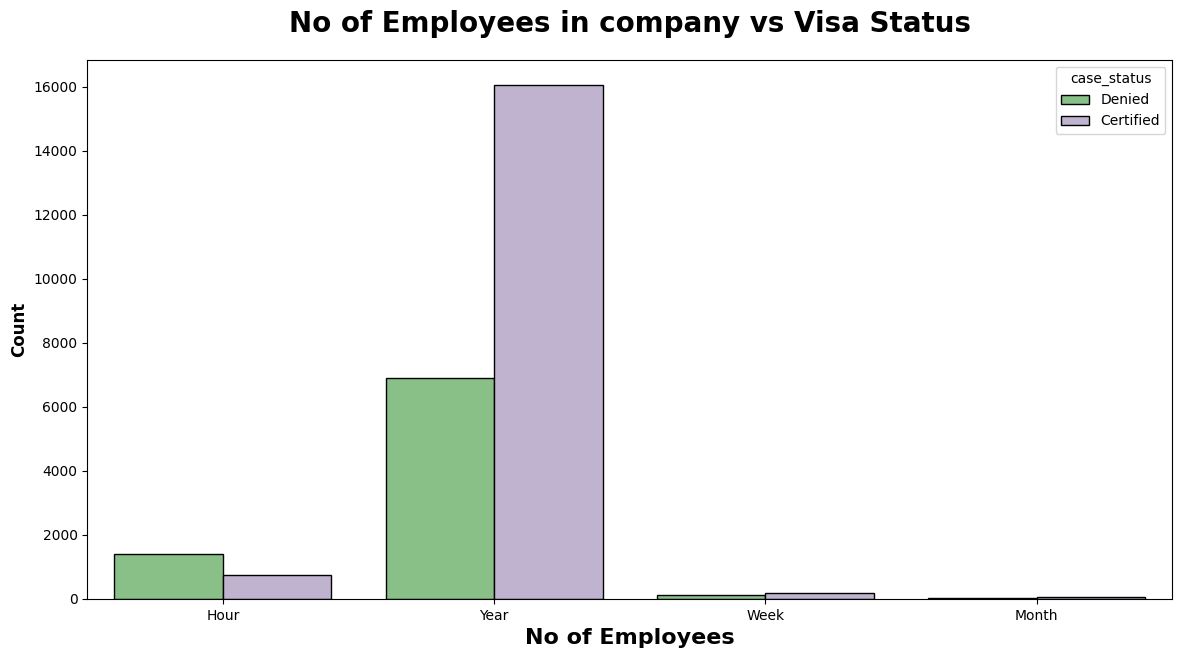

In [28]:
plt.subplots(figsize=(14,7))
sns.countplot(x="unit_of_wage", hue="case_status", data=df,ec='k',palette="Accent")
plt.title("No of Employees in company vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("No of Employees", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

**Report**
- For semployees who applied for hourly pay 65% of them were denied.
- Yearly unit wage application were accepted for 69% and denied for 31% of the time.
- There is a higher chance of yearly contract than other and immediately followed by week and month.

# Does region of employement has impact on Visa Status?

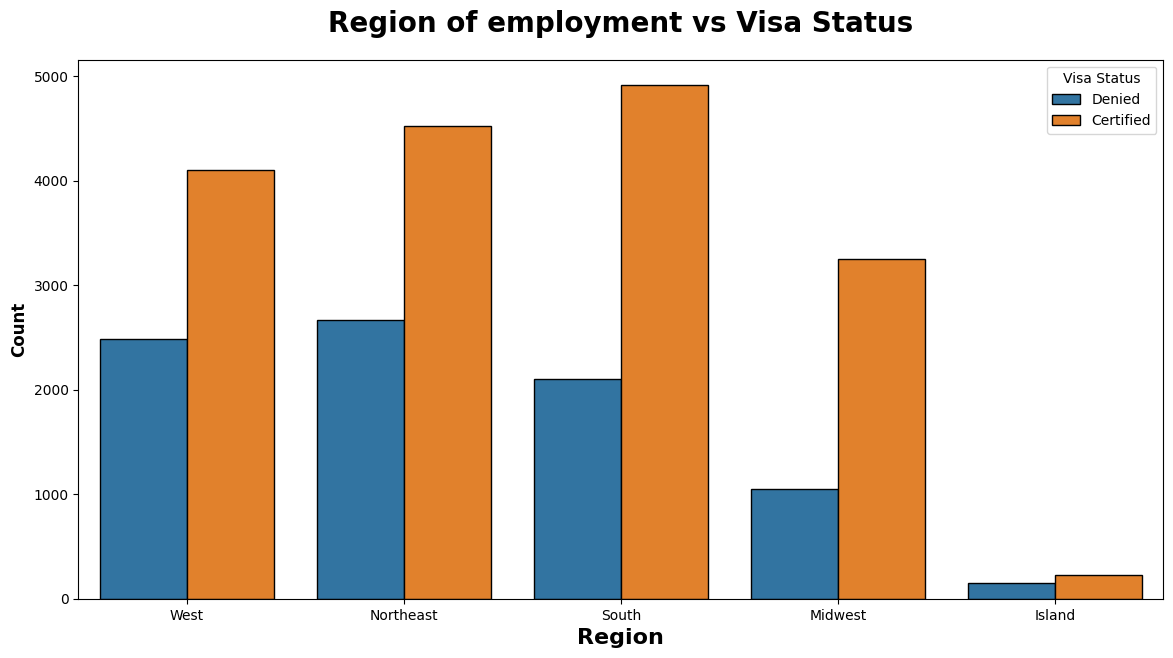

In [29]:
plt.subplots(figsize=(14,7))
sns.countplot(x='region_of_employment', hue="case_status", data=df, ec='k')
plt.title("Region of employment vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

# Does Prevailing wage has any impact on Visa Status?

In [30]:
df.groupby('prevailing_wage').case_status.value_counts()

prevailing_wage  case_status
2.1367           Certified      1
2.9561           Denied         1
3.0031           Denied         1
3.3188           Denied         1
3.4889           Certified      1
                               ..
311734.4900      Certified      1
314156.0600      Certified      1
315497.6000      Certified      1
318446.0500      Certified      1
319210.2700      Denied         1
Name: count, Length: 25462, dtype: int64

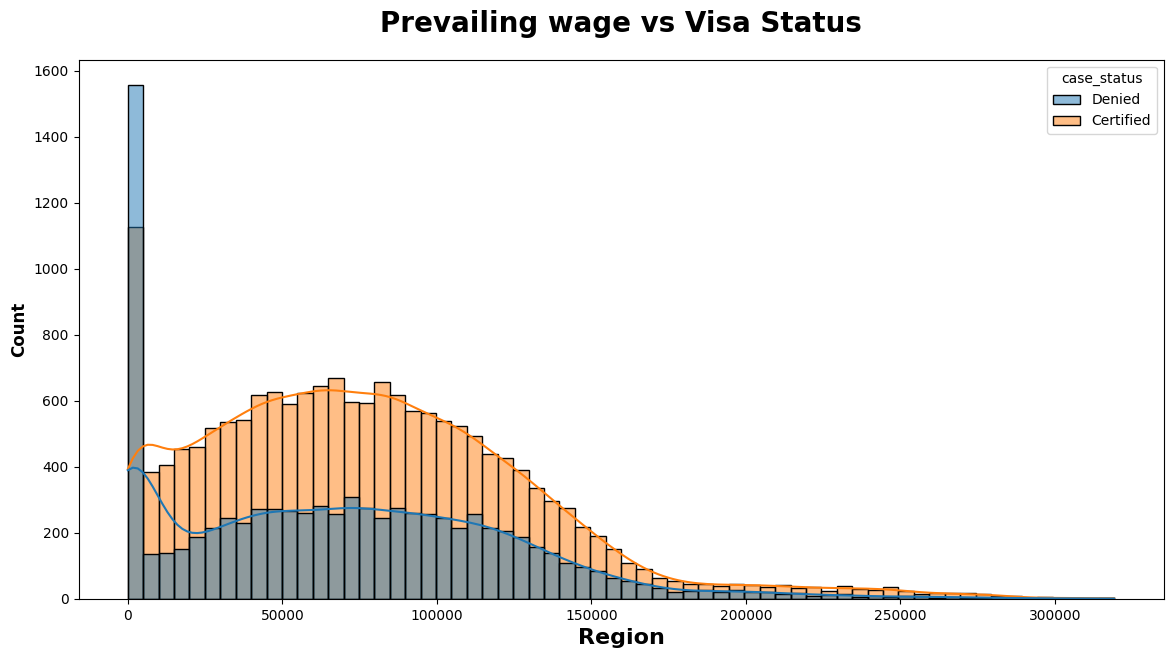

In [31]:
plt.subplots(figsize=(14,7))
sns.histplot(x="prevailing_wage", hue="case_status", data=df, kde=True)
plt.title("Prevailing wage vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("Region", weight='bold', fontsize=16)
plt.ylabel("Count", weight='bold', fontsize=12)
plt.show()

**Insight**
- The distribution of both the classes are same but need to handle the Outliers.

# Prevailing wage based on Education

In [32]:
print("Average Prevailing wage based on employee education.")
df.groupby('education_of_employee')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage', ascending=False)

Average Prevailing wage based on employee education.


,prevailing_wage
education_of_employee,
Master's,78843.057843
Bachelor's,73405.443735
High School,71582.147756
Doctorate,64561.076657


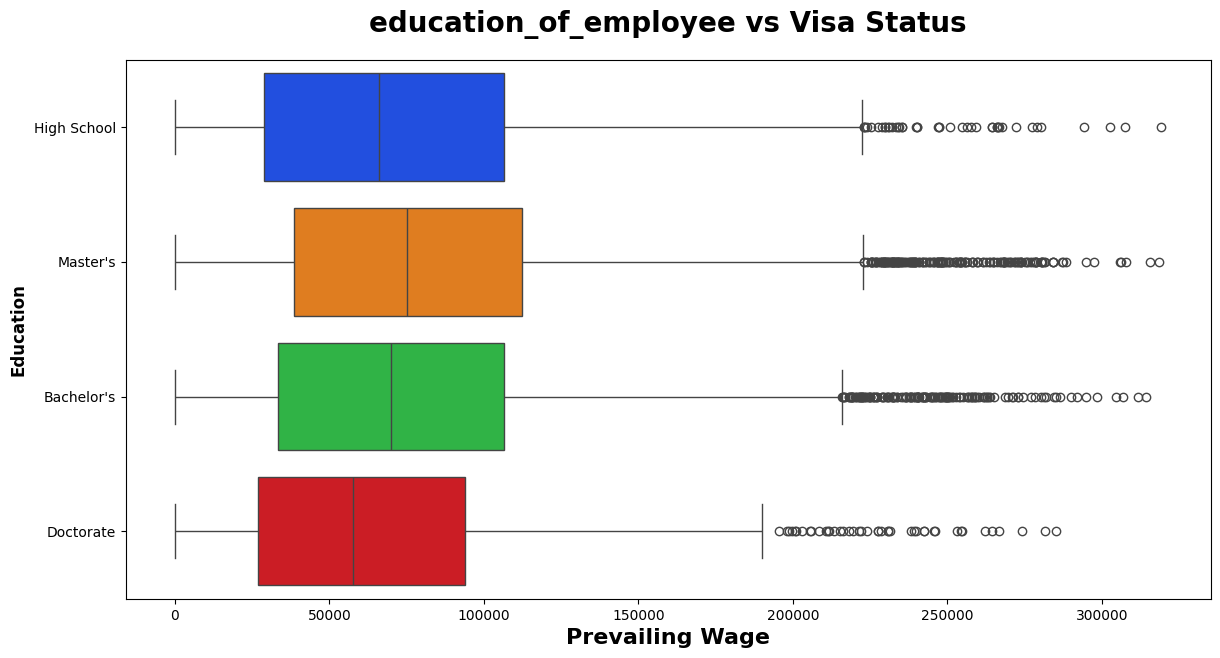

In [33]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="education_of_employee", x="prevailing_wage", data=df,palette='bright')
plt.title("education_of_employee vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("Education", weight="bold", fontsize=12)
plt.show()

**Report**
- Based on the above table and charts its seen that applicant with Master's education has higher average prevailin wages
- Master's education applicants have median salary of $78.8k, which approximately 20% higher than Doctorate's average wage, which is strange.

# Prevailing wage based on Job Experience

In [34]:
print('Median Prevailing weage based on job experience')
df.groupby('has_job_experience')['prevailing_wage'].median().to_frame().sort_values(by='prevailing_wage', ascending=False)

Median Prevailing weage based on job experience


,prevailing_wage
has_job_experience,
N,72602.290
Y,69033.665


**Report**
- Suprisingly People who has no job experience has more prevailing wage.
- No job experience applicant has median Prevailing wage as 72k USD.
- Previous Job experience applicant has median prevailing wage as 69k USD.

# Prevailing wage based on continent

In [35]:
print('Average Prevailing wage based on continent')
df.groupby('continent')['prevailing_wage'].median().to_frame().sort_values(by='prevailing_wage', ascending=False)

Average Prevailing wage based on continent


,prevailing_wage
continent,
Asia,76168.880
Africa,75126.310
Oceania,68656.045
North America,64289.875
South America,53511.705
Europe,52073.335


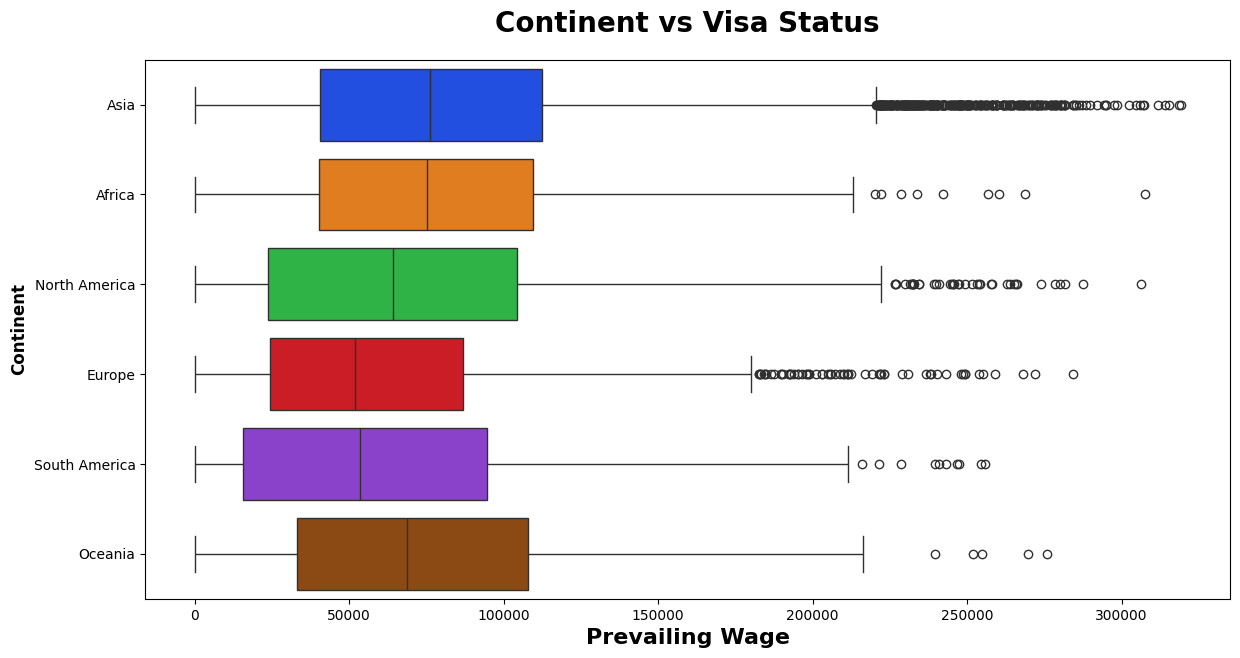

In [36]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="continent", x="prevailing_wage", data=df,palette='bright')
plt.title("Continent vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("Continent", weight="bold", fontsize=12)
plt.show()

**Report**
- Average salary of people from Asia is higher than other countries.

# Year of Establisment

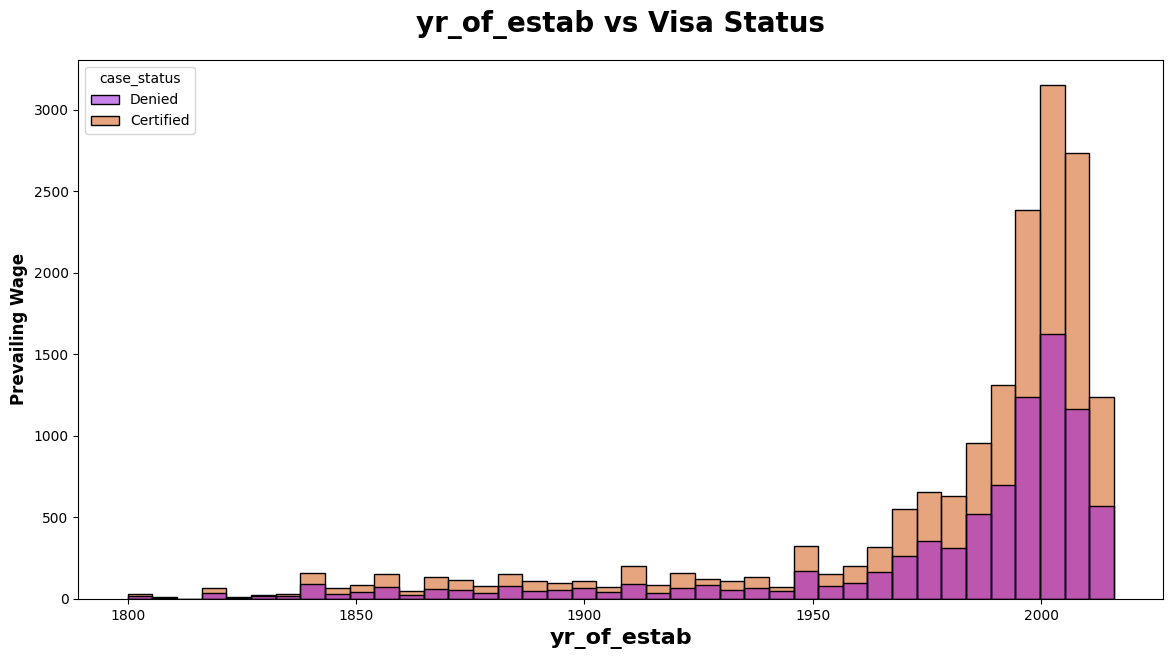

In [37]:
plt.subplots(figsize=(14,7))
sns.histplot(x="yr_of_estab", data=df,palette='gnuplot', bins=40,hue='case_status')
plt.title("yr_of_estab vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("yr_of_estab", weight="bold", fontsize=16)
plt.ylabel("Prevailing Wage", weight="bold", fontsize=12)
plt.show()

**Report**
- Each bins consist of 5 syears.
- many Companies were established in year 2000.
- The most company establishment happened in year 2000-2005.

**Final Report**
- **case_id** column can be droped as it is an ID.
- **requires_job_training** column can be dropped as it doesn't have much impact on target variable, Proved in Visualization and chi2 test.
- **no_of_employees, prevailing_wage** columns have outlier which should be handled.
- **continent** column has few unique value with very less count, which can be made as **others**.
- Target column **case_status** is imbalanced can be handled before model building.